# 85 - Fine-tuning VGG-16

**Section:** Transfer Learning | **Prereqs:** `Transfer Learning/TF_ResNet-18.ipynb` | **Next:** `Transfer Learning/Pretraining_CIFAR-10.ipynb`

The same STL-10 task with VGG-16 instead of ResNet-18, which makes the
architectural contrast the lesson.

| | ResNet-18 | VGG-16 |
|---|---|---|
| Parameters | ~11M | ~138M |
| Classifier head | one `Linear(512,10)` | three `Linear` layers, ~120M parameters |
| Depth | 18 layers with residual connections | 16 plain stacked layers |
| Replace the head via | `model.fc = ...` | `model.classifier[6] = ...` |

**Most of VGG is its classifier.** Around 90% of those 138M parameters sit in the
three fully connected layers - which is precisely the waste that
`CNNs/CodeChallenge_How_Wide_FC_Layer.ipynb` measured, and why ResNet's global
average pooling plus one small `Linear` is both smaller and better.

**The head is a `Sequential`,** so replacing it means indexing into it:
`vgg.classifier[6] = nn.Linear(4096, 10)`. Print the model first to find the
index - it differs between architectures, which is why there is no single line
that works everywhere.

**Note the learning rate: 1e-5, a hundred times smaller than the ResNet notebook's.**
VGG has no batch normalisation and its huge dense layers make it far more
sensitive; large steps destabilise it immediately.

**Check what you froze.** The loop matches on `'classifier' in name`, so both
weights and biases of the head train. Adding a `'weight' in name` condition would
silently leave the biases frozen - the kind of mistake that costs a point of
accuracy and never announces itself.

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader,TensorDataset, Subset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler

import torchvision.models as models
import torchvision.datasets as datasets
import torchvision.transforms as T
import torchsummary

In [60]:
# STL-10: 96x96 colour, 10 classes, only 500 training images per class -
# deliberately small, which is exactly the situation transfer learning is for.
# The Normalize values are ImageNet's channel means and standard deviations. Use
# these EXACT numbers with any ImageNet-pretrained model: it was trained on
# inputs normalised this way, and different statistics shift every activation
# away from what its weights expect.
# (The comment says 'ResNet paper' - these are the standard ImageNet statistics,
# used by every torchvision pretrained model including VGG.)
transformations = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # These numbers are recommended in the ResNet Paper
])

trainset = datasets.STL10(root='/',split='train', download=True, transform=transformations)
testset = datasets.STL10(root='/',split='test', download=True, transform=transformations)

In [61]:
device = ('cuda' if torch.cuda.is_available() else 'cpu')
device

'cuda'

In [62]:
trainset

Dataset STL10
    Number of datapoints: 5000
    Root location: /
    Split: train
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
           )

In [63]:
bs = 32
train_loader = DataLoader(trainset, batch_size=bs, drop_last=True,shuffle=True)
test_loader = DataLoader(testset, batch_size=256)

In [64]:
# Shapes and class names.
print("Train data shape")
print(trainset.data.shape, trainset.labels.shape)


print("\nTest data shape")
print(testset.data.shape, testset.labels.shape)

print("\nCategories")
print(testset.classes)

Train data shape
(5000, 3, 96, 96) (5000,)

Test data shape
(8000, 3, 96, 96) (8000,)

Categories
['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']


In [65]:
X,y = next(iter(train_loader))

print(X.shape, y.shape)

print("\nMin and Max vals:")
print(torch.min(X), torch.max(X))

torch.Size([32, 3, 96, 96]) torch.Size([32])

Min and Max vals:
tensor(-2.1179) tensor(2.6400)


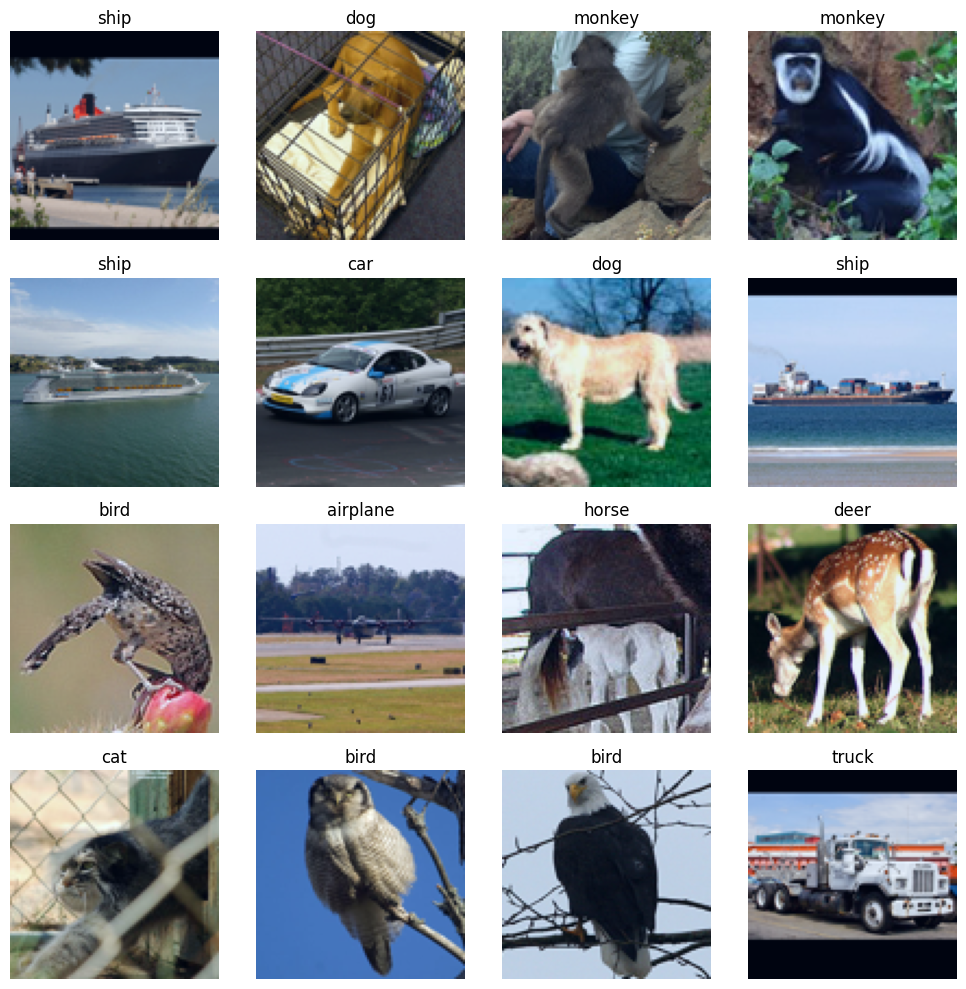

In [66]:
# Sample images, un-normalised for display.
fig, axs = plt.subplots(4,4,figsize=(10,10))
for (i, ax) in enumerate(axs.flatten()) :
    if i >= len(X):
        break

    # extract that image (need to transpose it back to HxWxC from CxHxW)
    pic = X[i].numpy().transpose((1,2,0))

    # undo normalization (rescale to 0-1 for display)
    pic = pic - np.min(pic)
    # Avoid division by zero if all pixels are the same value (e.g., all zeros)
    if np.max(pic) > 0:
        pic = pic / np.max(pic)

    # and its label (convert tensor to Python scalar for indexing)
    label = trainset.classes[y[i].item()]
    ax.imshow(pic)
    ax.set_title(label)
    ax.axis('off')

plt.tight_layout()
plt.show()

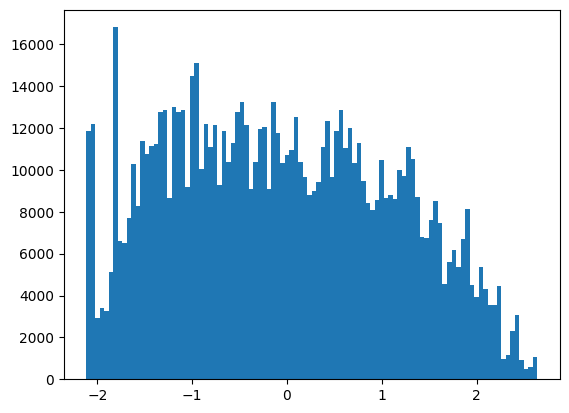

In [67]:
plt.hist(X.data.numpy().flatten(),100);

In [68]:
# VGG-16 with ImageNet weights.
# Print it: `features` is the convolutional stack, `avgpool`, then `classifier`,
# a Sequential of three Linear layers with dropout. Plain stacked 3x3 convolutions
# - no residual connections, no batch norm.
vgg = models.vgg16(weights=models.VGG16_Weights.DEFAULT)
print(vgg)

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [69]:
# The summary. Compare the parameter count with ResNet-18: ~138M against ~11M,
# and roughly 90% of VGG's sit in those three dense layers.
torchsummary.summary(vgg.to(device), input_size=(3,96,96), batch_size=bs)

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [32, 64, 96, 96]           1,792
              ReLU-2           [32, 64, 96, 96]               0
            Conv2d-3           [32, 64, 96, 96]          36,928
              ReLU-4           [32, 64, 96, 96]               0
         MaxPool2d-5           [32, 64, 48, 48]               0
            Conv2d-6          [32, 128, 48, 48]          73,856
              ReLU-7          [32, 128, 48, 48]               0
            Conv2d-8          [32, 128, 48, 48]         147,584
              ReLU-9          [32, 128, 48, 48]               0
        MaxPool2d-10          [32, 128, 24, 24]               0
           Conv2d-11          [32, 256, 24, 24]         295,168
             ReLU-12          [32, 256, 24, 24]               0
           Conv2d-13          [32, 256, 24, 24]         590,080
             ReLU-14          [32, 256,

In [70]:
# Inspecting classifier[6], the final 4096 -> 1000 layer, to confirm the index
# before replacing it.
vgg.classifier[6]

Linear(in_features=4096, out_features=1000, bias=True)

In [71]:
# Replacing the head. Because the classifier is an nn.Sequential, this is index
# assignment rather than the attribute assignment ResNet needed (model.fc = ...).
# Print the model to find the right index - it is architecture-specific.
vgg.classifier[6] = nn.Linear(4096,10)

In [72]:
# Confirming the output is now 10 classes.
print('Check after changing the fc layer')
torchsummary.summary(vgg.to(device), input_size=(3,96,96), batch_size=bs)

Check after changing the fc layer
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [32, 64, 96, 96]           1,792
              ReLU-2           [32, 64, 96, 96]               0
            Conv2d-3           [32, 64, 96, 96]          36,928
              ReLU-4           [32, 64, 96, 96]               0
         MaxPool2d-5           [32, 64, 48, 48]               0
            Conv2d-6          [32, 128, 48, 48]          73,856
              ReLU-7          [32, 128, 48, 48]               0
            Conv2d-8          [32, 128, 48, 48]         147,584
              ReLU-9          [32, 128, 48, 48]               0
        MaxPool2d-10          [32, 128, 24, 24]               0
           Conv2d-11          [32, 256, 24, 24]         295,168
             ReLU-12          [32, 256, 24, 24]               0
           Conv2d-13          [32, 256, 24, 24]         590,080
     

In [73]:
# Every parameter is trainable before freezing.
for name, params in vgg.named_parameters():

  print(f'{name} : {params.requires_grad}')

features.0.weight : True
features.0.bias : True
features.2.weight : True
features.2.bias : True
features.5.weight : True
features.5.bias : True
features.7.weight : True
features.7.bias : True
features.10.weight : True
features.10.bias : True
features.12.weight : True
features.12.bias : True
features.14.weight : True
features.14.bias : True
features.17.weight : True
features.17.bias : True
features.19.weight : True
features.19.bias : True
features.21.weight : True
features.21.bias : True
features.24.weight : True
features.24.bias : True
features.26.weight : True
features.26.bias : True
features.28.weight : True
features.28.bias : True
classifier.0.weight : True
classifier.0.bias : True
classifier.3.weight : True
classifier.3.bias : True
classifier.6.weight : True
classifier.6.bias : True


In [74]:
# Freeze the convolutional backbone, train the classifier - weights AND biases.
# Matching on 'classifier' alone is what you want here; adding `and 'weight' in
# name` would leave the classifier's biases frozen, which is easy to write by
# accident and invisible afterwards.
for name, params in vgg.named_parameters():
    if 'classifier' in name:
        params.requires_grad = True
    else:
        params.requires_grad = False

In [75]:
# Verify the freeze.
# Checking if the layers are frozen
for name, params in vgg.named_parameters():

  print(f'{name} : {params.requires_grad}')

features.0.weight : False
features.0.bias : False
features.2.weight : False
features.2.bias : False
features.5.weight : False
features.5.bias : False
features.7.weight : False
features.7.bias : False
features.10.weight : False
features.10.bias : False
features.12.weight : False
features.12.bias : False
features.14.weight : False
features.14.bias : False
features.17.weight : False
features.17.bias : False
features.19.weight : False
features.19.bias : False
features.21.weight : False
features.21.bias : False
features.24.weight : False
features.24.bias : False
features.26.weight : False
features.26.bias : False
features.28.weight : False
features.28.bias : False
classifier.0.weight : True
classifier.0.bias : False
classifier.3.weight : True
classifier.3.bias : False
classifier.6.weight : True
classifier.6.bias : False


In [76]:
# lr=1e-5, a hundred times smaller than the ResNet notebook's.
# VGG has no batch normalisation and enormous dense layers, so it is far more
# sensitive to step size. Learning rate is architecture-dependent - there is no
# value that transfers between models.
def train_model():

  lossfunc = nn.CrossEntropyLoss()
  epochs = 10
  optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, vgg.parameters()),
    lr=1e-5,
)

  losses = []
  train_acc = []
  val_acc = []



  for epoch in range(epochs):

    vgg.train()

    batch_acc = []
    batch_loss = []

    for x,y in train_loader:
      x = x.to(device)
      y = y.to(device)

      yhat = vgg(x)

      loss = lossfunc(yhat,y)

      batch_loss.append(loss.item())

      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      acc = 100 * torch.mean( (torch.argmax(yhat, dim=1) == y).float().detach().cpu())
      batch_acc.append(acc)

    losses.append(np.mean(batch_loss))
    train_acc.append(np.mean(batch_acc))

    # Now validation

    vgg.eval()
    with torch.no_grad():
      batch_val_acc = []
      for X, Y in test_loader:
        X = X.to(device)
        Y = Y.to(device)
        batch_val_acc.append( 100 * torch.mean( (torch.argmax(vgg(X), dim=1) == Y).float().detach().cpu()) )
      val_acc.append(np.mean(batch_val_acc))


    if epoch % 10 == 0 or epoch == epochs-1 :
      print(f'Epoch {epoch} | Loss : {losses[epoch]:.4f} | Train Acc {train_acc[epoch]} | Val Acc : {val_acc[epoch]}')

  return vgg, losses, train_acc, val_acc

In [77]:
# Train. Slower per epoch than ResNet despite training fewer layers, because
# every forward pass runs 138M parameters.
vgg, losses, train_acc, val_acc = train_model()

Epoch 0 | Loss : 1.3681 | Train Acc 56.00961685180664 | Val Acc : 88.34228515625
Epoch 9 | Loss : 0.0601 | Train Acc 98.2371826171875 | Val Acc : 92.49267578125


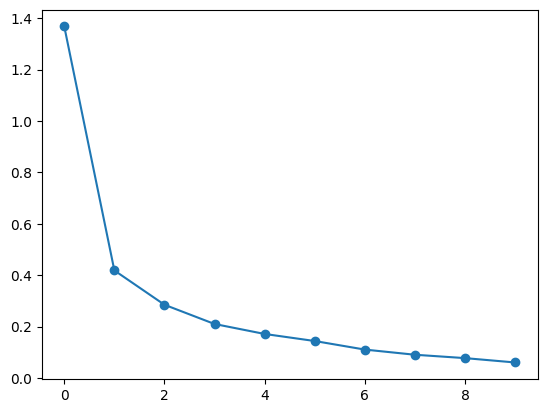

In [78]:
# Loss curve. Compare the accuracy and the wall-clock time against ResNet-18:
# more parameters is not more accuracy, which is the whole architectural lesson
# of the years between VGG (2014) and ResNet (2015).
plt.plot(losses,'o-');

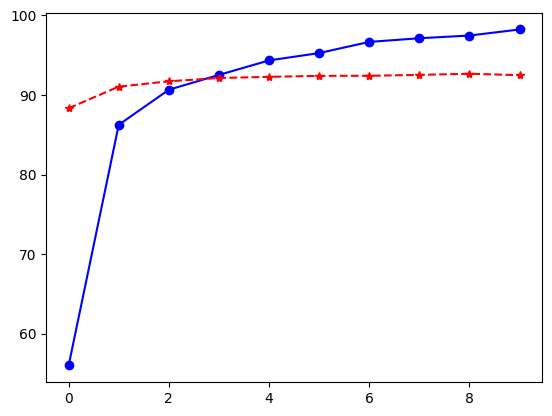

In [79]:
plt.plot(train_acc,'bo-')
plt.plot(val_acc, 'r*--');

In [80]:
help(filter)

Help on class filter in module builtins:

class filter(object)
 |  filter(function or None, iterable) --> filter object
 |
 |  Return an iterator yielding those items of iterable for which function(item)
 |  is true. If function is None, return the items that are true.
 |
 |  Methods defined here:
 |
 |  __getattribute__(self, name, /)
 |      Return getattr(self, name).
 |
 |  __iter__(self, /)
 |      Implement iter(self).
 |
 |  __next__(self, /)
 |      Implement next(self).
 |
 |  __reduce__(...)
 |      Return state information for pickling.
 |
 |  ----------------------------------------------------------------------
 |  Static methods defined here:
 |
 |  __new__(*args, **kwargs)
 |      Create and return a new object.  See help(type) for accurate signature.

